In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, auc, accuracy_score,  classification_report, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

In [4]:
df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'))
df_sissiz_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx'))
df_multiperm_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'))
df_multiperm_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx'))
df_aln_shuffle = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'))

## Confusion Matrix

In [5]:
def plot_confusion_matrix(cm, title="Confusion Matrix", ax=None):
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')
    ax.xaxis.set_ticklabels(['False', 'True'])
    ax.yaxis.set_ticklabels(['False', 'True'])

## ROC-Curve

In [6]:
def plot_roc_curve(fper, tper, title="ROC Curve", ax=None):
    roc_auc = auc(fper, tper)
    ax.plot(fper, tper, color='red', label=f'ROC curve (area = {roc_auc:0.2f})')
    ax.plot([0, 1], [0, 1], color='green', linestyle='--', label='No Skill')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()

# Logistische Regressions Auswertung

In [69]:
def logistic_regression_pipeline(data, target_column='z-score calculated from 7. 8. and 9.', threshold=0, class_weights={0: 1, 1: 3}):

    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    

    # Standardisierung des z-scores
    data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score"] > threshold, 1, 0)

    # Erstellen der 'label' Spalte mit dem Schwellenwert
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Logistische Regression trainieren
    log_reg = LogisticRegression(class_weight=class_weights, max_iter=1000, random_state=0)
    log_reg.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(log_reg, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = log_reg.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)
    print("False-Negative Rate: ", 1 - cm[1][0] / (cm[1][0] + cm[1][1]))

    # Schritt 5: ROC-Kurve und AUC berechnen
    y_test_prob = log_reg.predict_proba(X_test)[:, 1]
    fper, tper, thresholds = roc_curve(y_test, y_test_prob)
    auc_score = roc_auc_score(y_test, y_test_prob)
    print(f"AUC score: {auc_score}")
   
    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, "Confusion Matrix: Logistische Regression", ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, "ROC Curve: Logistische Regression", ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()  # Optional: Verbessert das Layout
    plt.show()

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    27777
0    22223
Name: count, dtype: int64
y_test label
1    27834
0    22166
Name: count, dtype: int64
Cross-validation scores: [0.9958 0.9946 0.9936 0.9942 0.9956 0.9934 0.9956 0.9954 0.995  0.9954]
Mean CV score: 0.9948599999999999
Accuracy score:  0.99412
False-Negative Rate:  1.0
AUC score: 0.9999961991573105


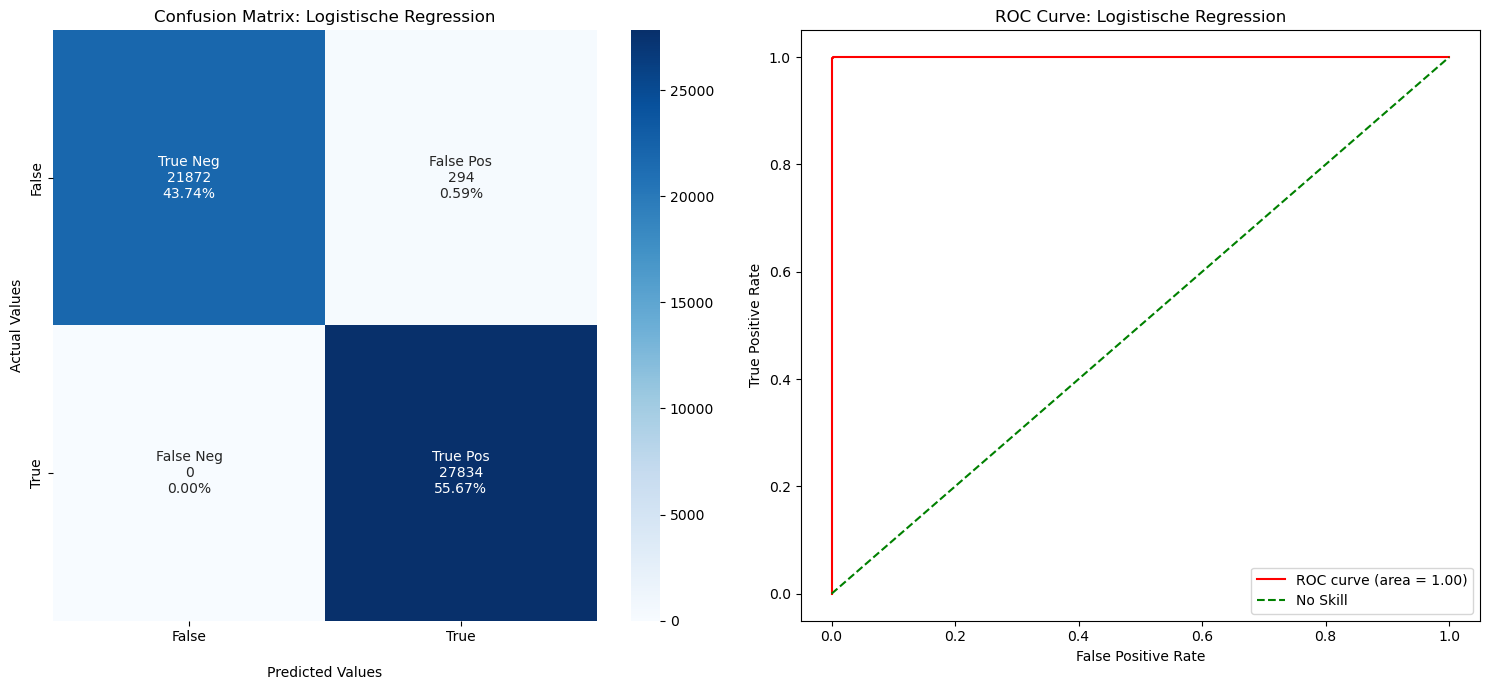

In [70]:
logistic_regression_pipeline(df_sissiz_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    27777
0    22223
Name: count, dtype: int64
y_test label
1    27834
0    22166
Name: count, dtype: int64
Cross-validation scores: [0.9958 0.9946 0.9936 0.9942 0.9956 0.9934 0.9956 0.9954 0.995  0.9954]
Mean CV score: 0.9948599999999999
Accuracy score:  0.99412
False-Negative Rate:  1.0
AUC score: 0.9999961991573105


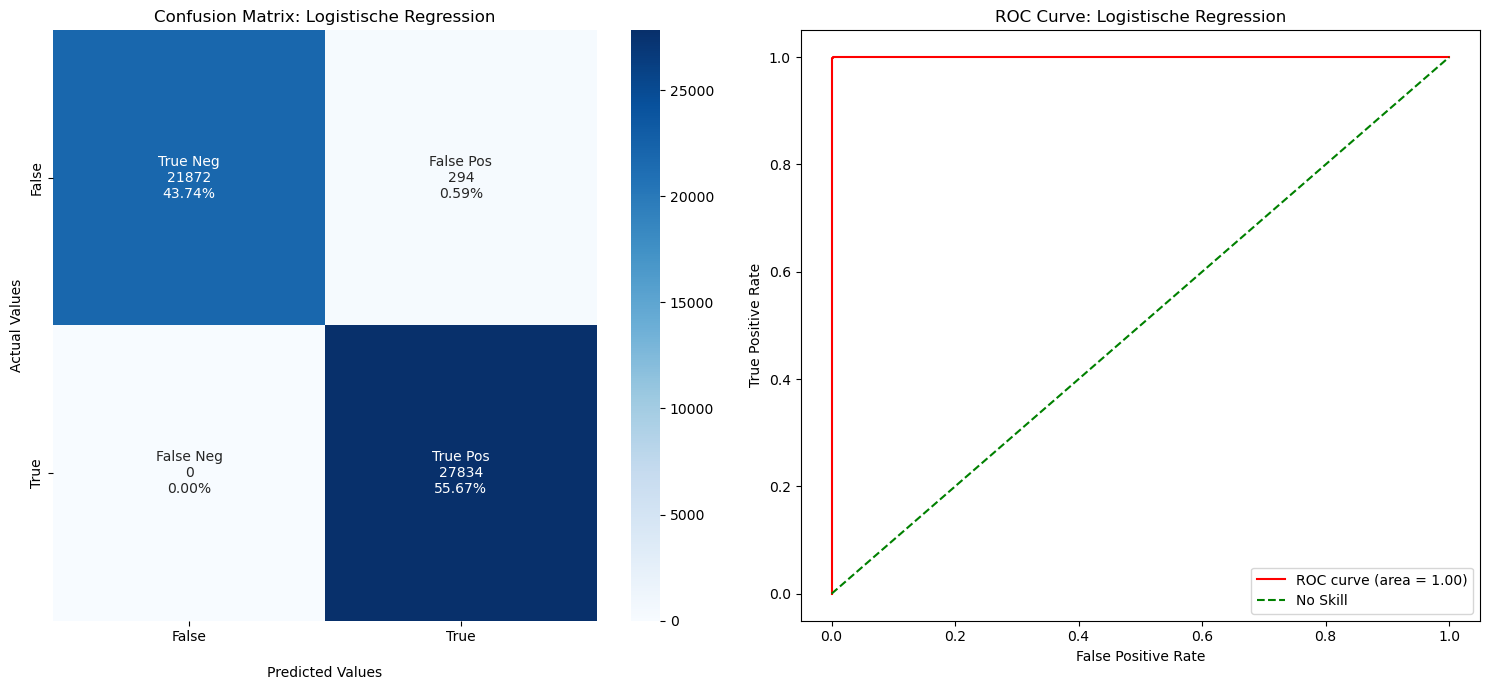

In [71]:
logistic_regression_pipeline(df_sissiz_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26429
0    23571
Name: count, dtype: int64
y_test label
1    26484
0    23516
Name: count, dtype: int64
Cross-validation scores: [0.9924 0.9908 0.9914 0.99   0.9928 0.9922 0.9938 0.9906 0.9908 0.991 ]
Mean CV score: 0.9915799999999999
Accuracy score:  0.99214
False-Negative Rate:  1.0
AUC score: 0.9999915702970176


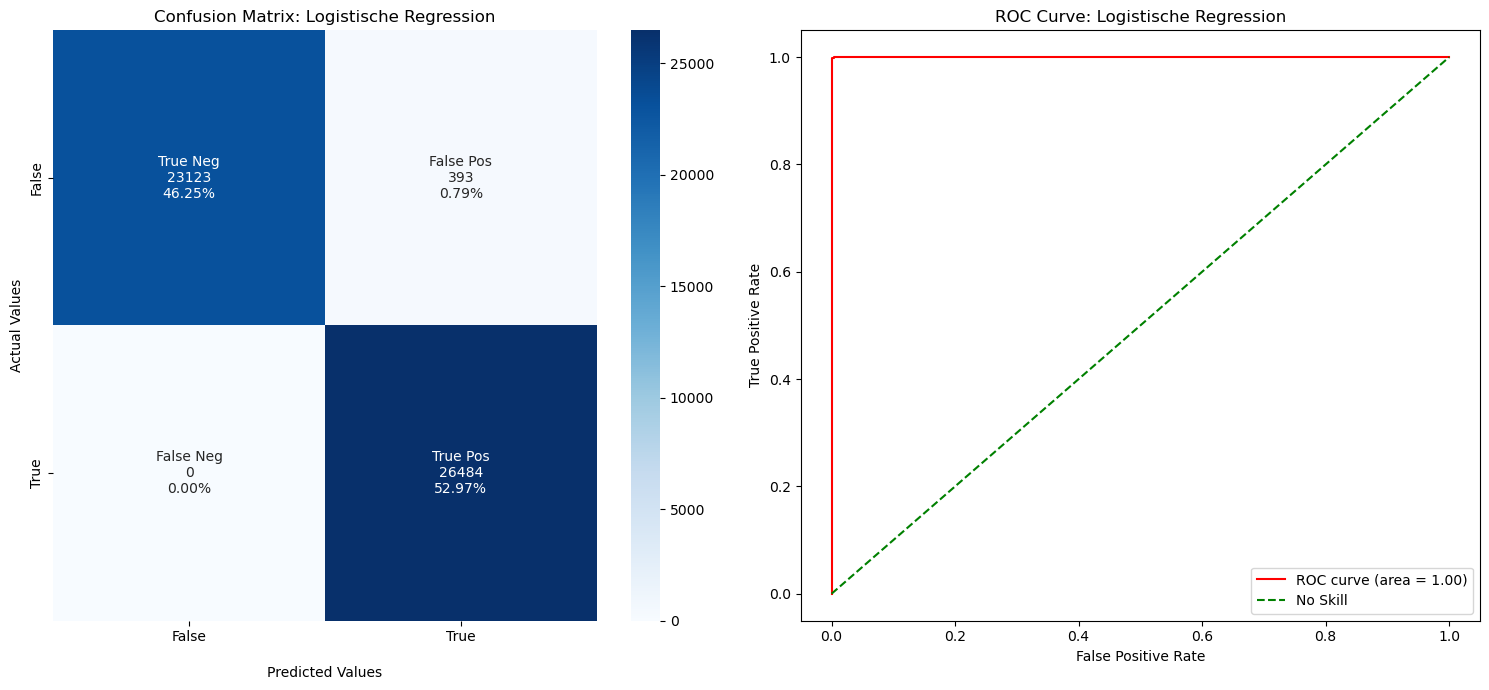

In [72]:
logistic_regression_pipeline(df_multiperm_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26380
0    23620
Name: count, dtype: int64
y_test label
1    26392
0    23608
Name: count, dtype: int64
Cross-validation scores: [0.9932 0.9942 0.9916 0.993  0.9924 0.991  0.9938 0.9924 0.9904 0.9898]
Mean CV score: 0.99218
Accuracy score:  0.99224
False-Negative Rate:  1.0
AUC score: 0.9999915530121211


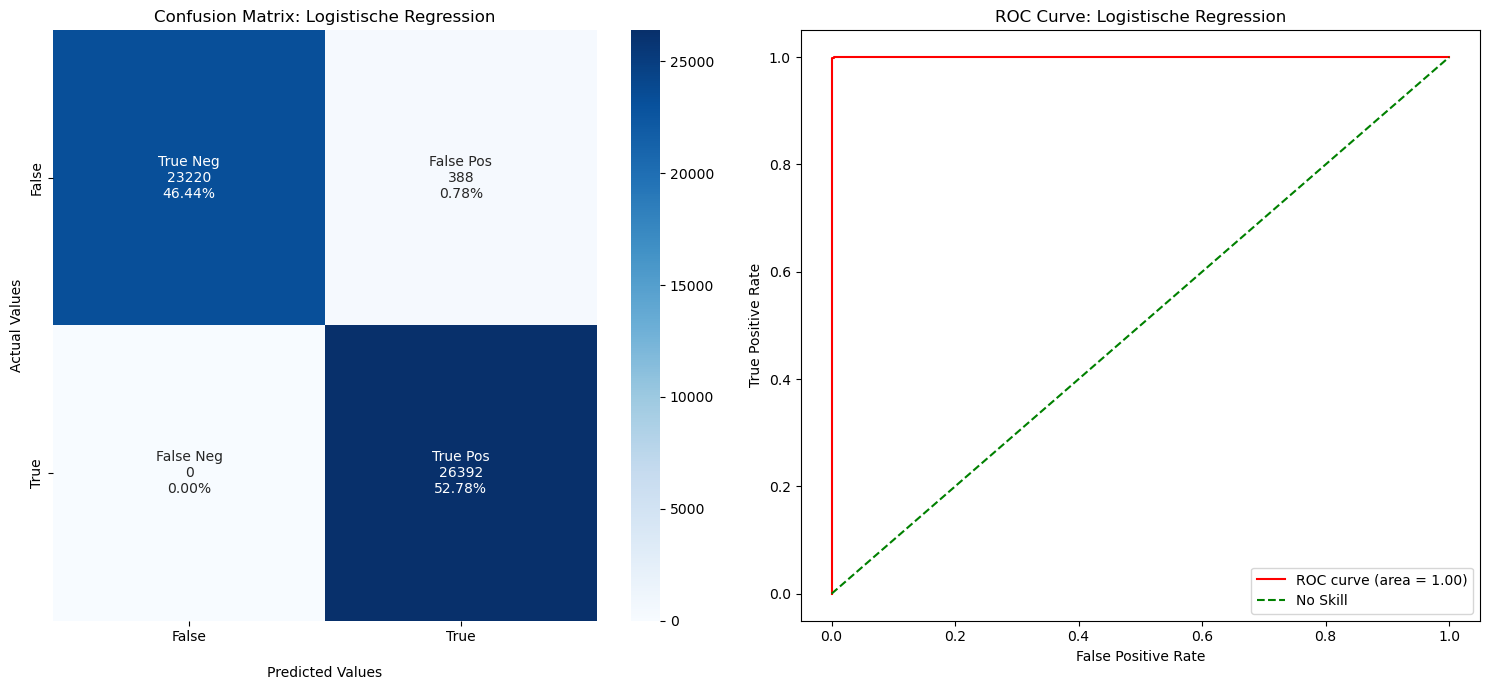

In [73]:
logistic_regression_pipeline(df_multiperm_di)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26450
0    23550
Name: count, dtype: int64
y_test label
1    26406
0    23594
Name: count, dtype: int64
Cross-validation scores: [0.9926 0.9916 0.9884 0.9938 0.9882 0.99   0.99   0.991  0.9898 0.991 ]
Mean CV score: 0.99064
Accuracy score:  0.99128
False-Negative Rate:  1.0
AUC score: 0.9999931671882428


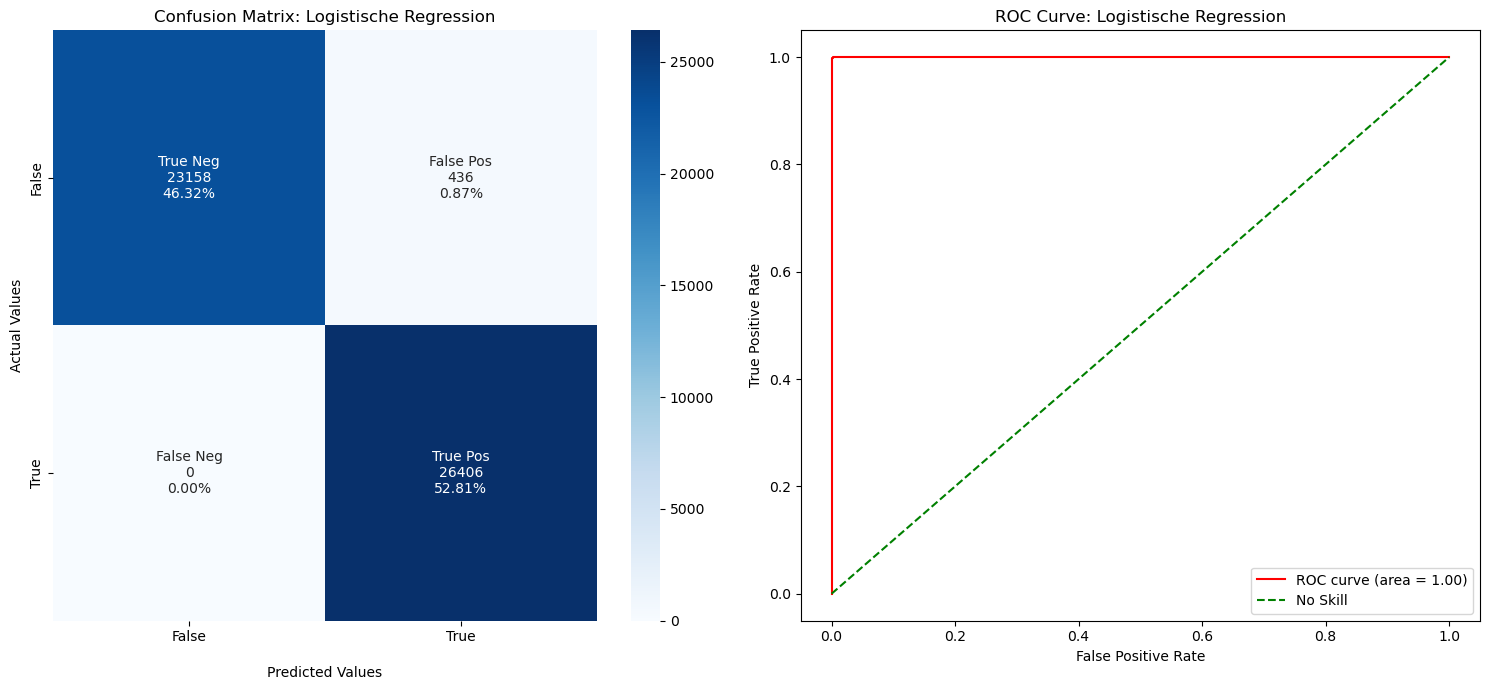

In [74]:
logistic_regression_pipeline(df_aln_shuffle)

# Random Forest

In [75]:
def random_forest_pipeline(data, target_column='z-score calculated from 7. 8. and 9.', threshold=0, class_weights={0: 1, 1: 3}):
    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    
    # Standardisierung des z-scores
    data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score"] > threshold, 1, 0)

    # Erstellen der 'label' Spalte mit dem Schwellenwert
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Random Forest trainieren
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight=class_weights, random_state=0)
    rf_model.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(rf_model, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = rf_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)

    if cm.shape == (2,2):  # Prüfe, ob die Confusion Matrix 2x2 ist
        false_negative_rate = 1 - cm[1][0] / (cm[1][0] + cm[1][1])
        print("False-Negative Rate: ", false_negative_rate)
    else:
        print("Warnung: Nur eine Klasse in y_test vorhanden, False-Negative Rate nicht berechenbar.")


    # Schritt 5: ROC-Kurve und AUC berechnen
    global y_test_prob
    y_test_prob = rf_model.predict_proba(X_test)[:, 1]
    fper, tper, _ = roc_curve(y_test, y_test_prob)

    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, "Confusion Matrix: Random Forest", ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, "ROC Curve: Random Forest", ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()
    plt.show()

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    27777
0    22223
Name: count, dtype: int64
y_test label
1    27834
0    22166
Name: count, dtype: int64
Cross-validation scores: [0.9114 0.901  0.8998 0.9056 0.9042 0.9034 0.904  0.9072 0.9042 0.9098]
Mean CV score: 0.90506
Accuracy score:  0.90418
False-Negative Rate:  0.9918085794352232


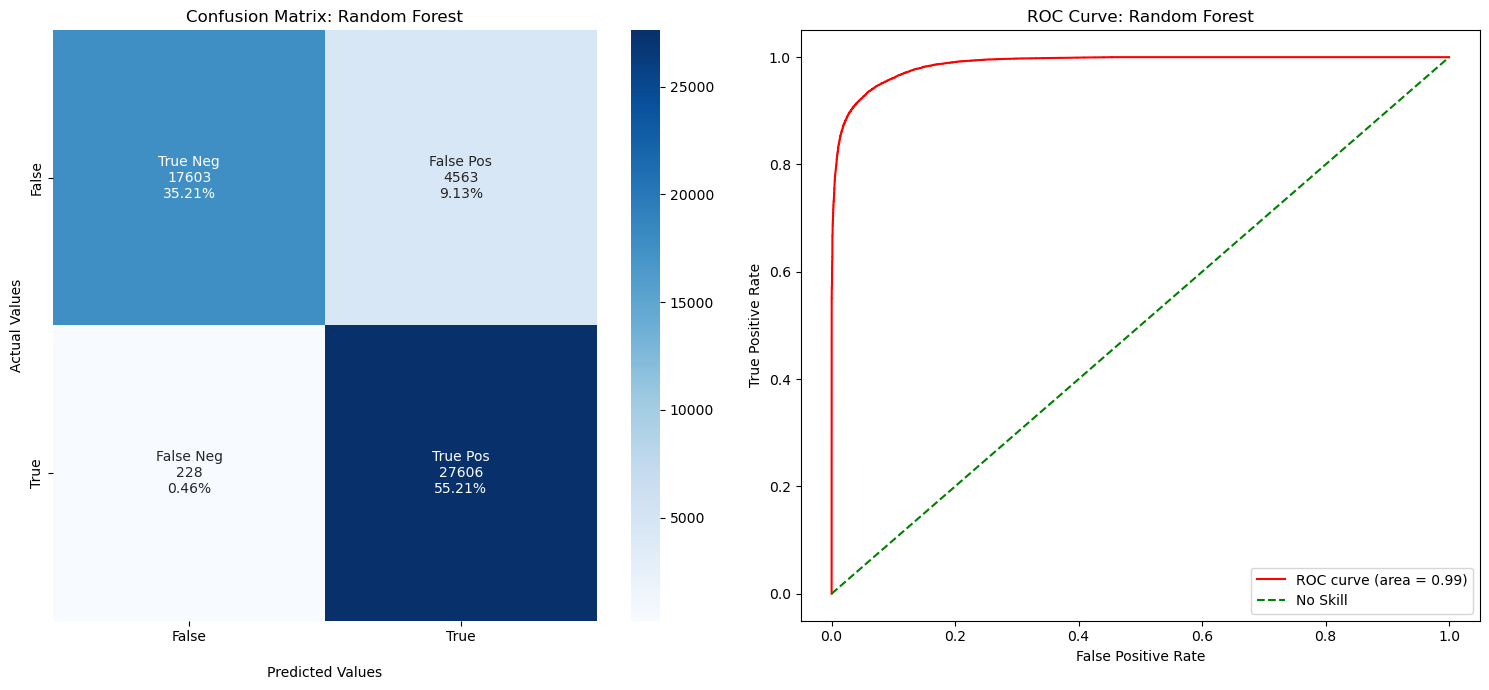

In [76]:
random_forest_pipeline(df_sissiz_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    27273
0    22727
Name: count, dtype: int64
y_test label
1    27264
0    22736
Name: count, dtype: int64
Cross-validation scores: [0.895  0.8934 0.899  0.8944 0.891  0.8878 0.89   0.8956 0.8972 0.8914]
Mean CV score: 0.8934799999999999
Accuracy score:  0.89432
False-Negative Rate:  0.9883362676056338


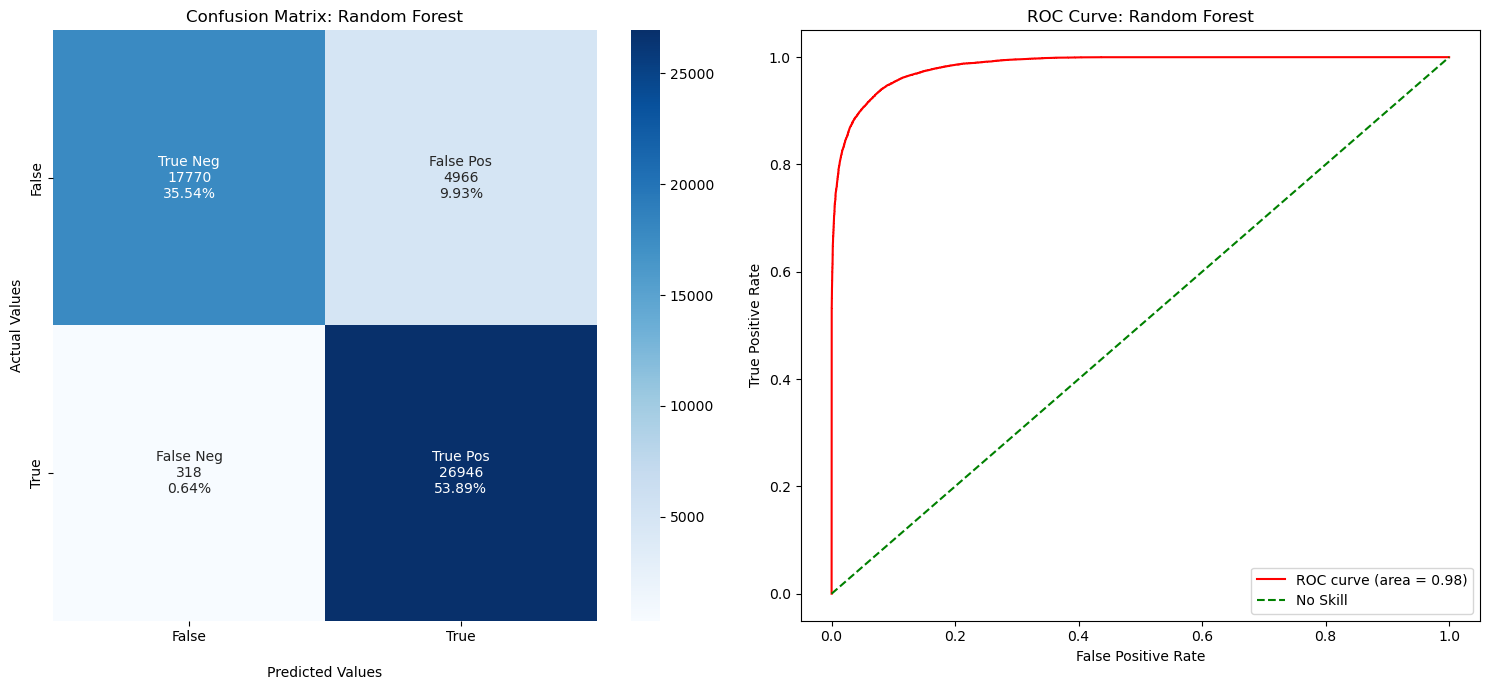

In [77]:
random_forest_pipeline(df_sissiz_di)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26429
0    23571
Name: count, dtype: int64
y_test label
1    26484
0    23516
Name: count, dtype: int64
Cross-validation scores: [0.8924 0.889  0.8958 0.8864 0.8794 0.8966 0.8968 0.89   0.8926 0.8884]
Mean CV score: 0.8907400000000001
Accuracy score:  0.89058
False-Negative Rate:  0.9938453405829935


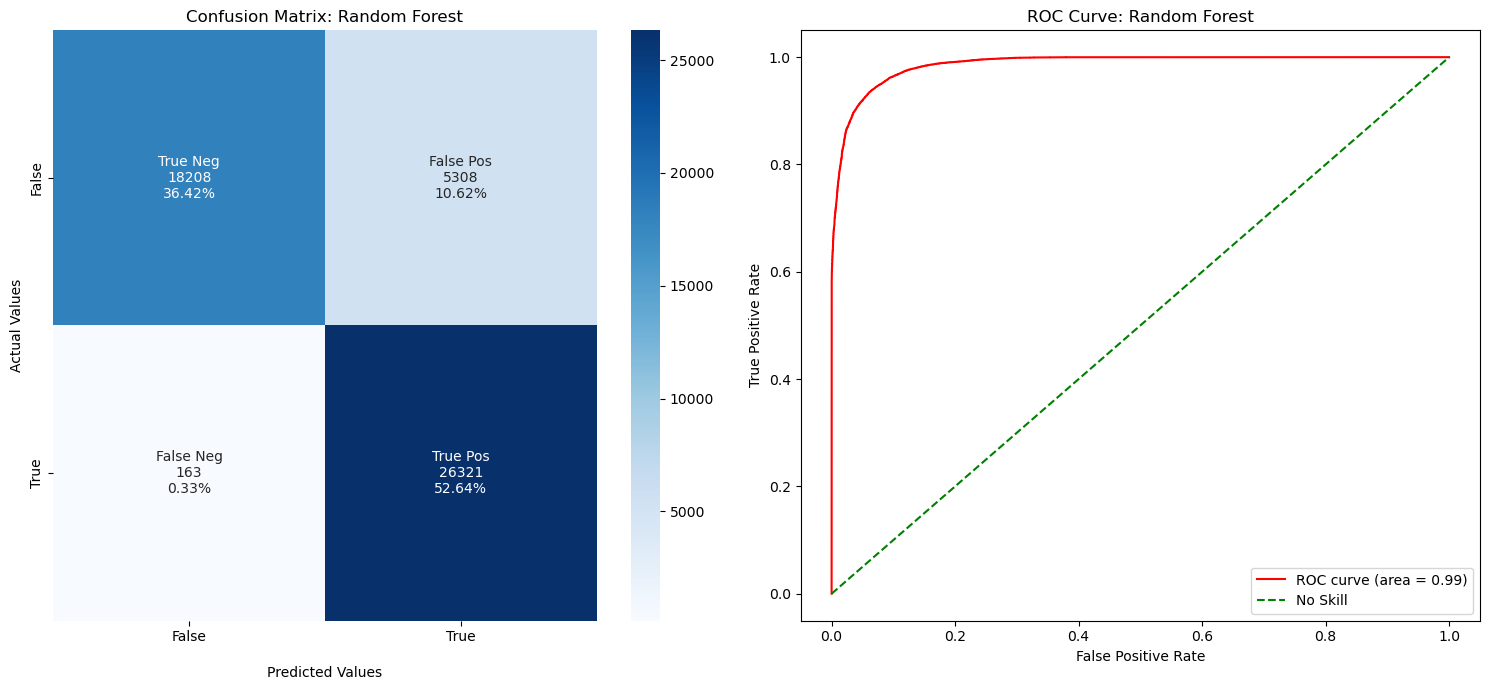

In [78]:
random_forest_pipeline(df_multiperm_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26380
0    23620
Name: count, dtype: int64
y_test label
1    26392
0    23608
Name: count, dtype: int64
Cross-validation scores: [0.8918 0.8906 0.8892 0.8894 0.8892 0.8874 0.878  0.8882 0.8876 0.8872]
Mean CV score: 0.8878599999999999
Accuracy score:  0.8871
False-Negative Rate:  0.9916262503789027


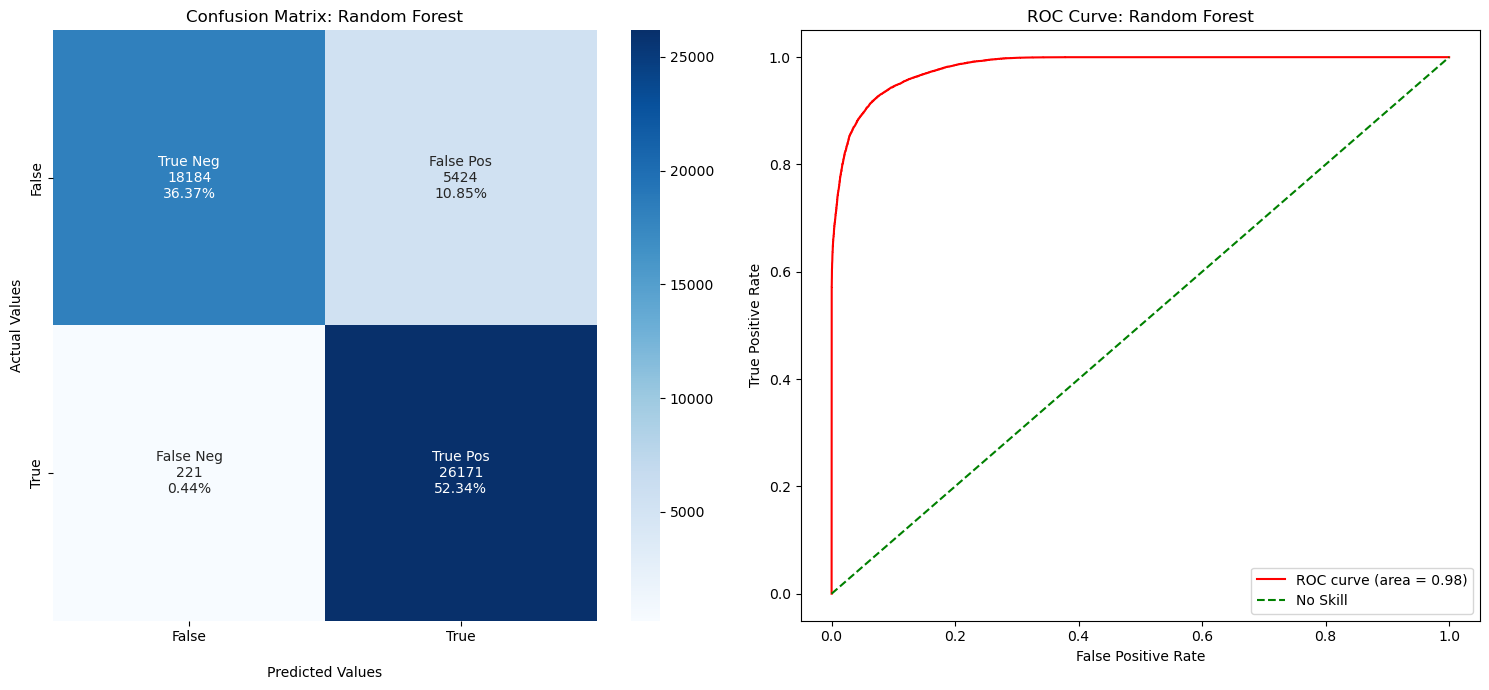

In [79]:
random_forest_pipeline(df_multiperm_di)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26450
0    23550
Name: count, dtype: int64
y_test label
1    26406
0    23594
Name: count, dtype: int64
Cross-validation scores: [0.907  0.9092 0.904  0.9066 0.9066 0.9062 0.8916 0.908  0.893  0.9052]
Mean CV score: 0.9037400000000002
Accuracy score:  0.90382
False-Negative Rate:  0.9952662273725669


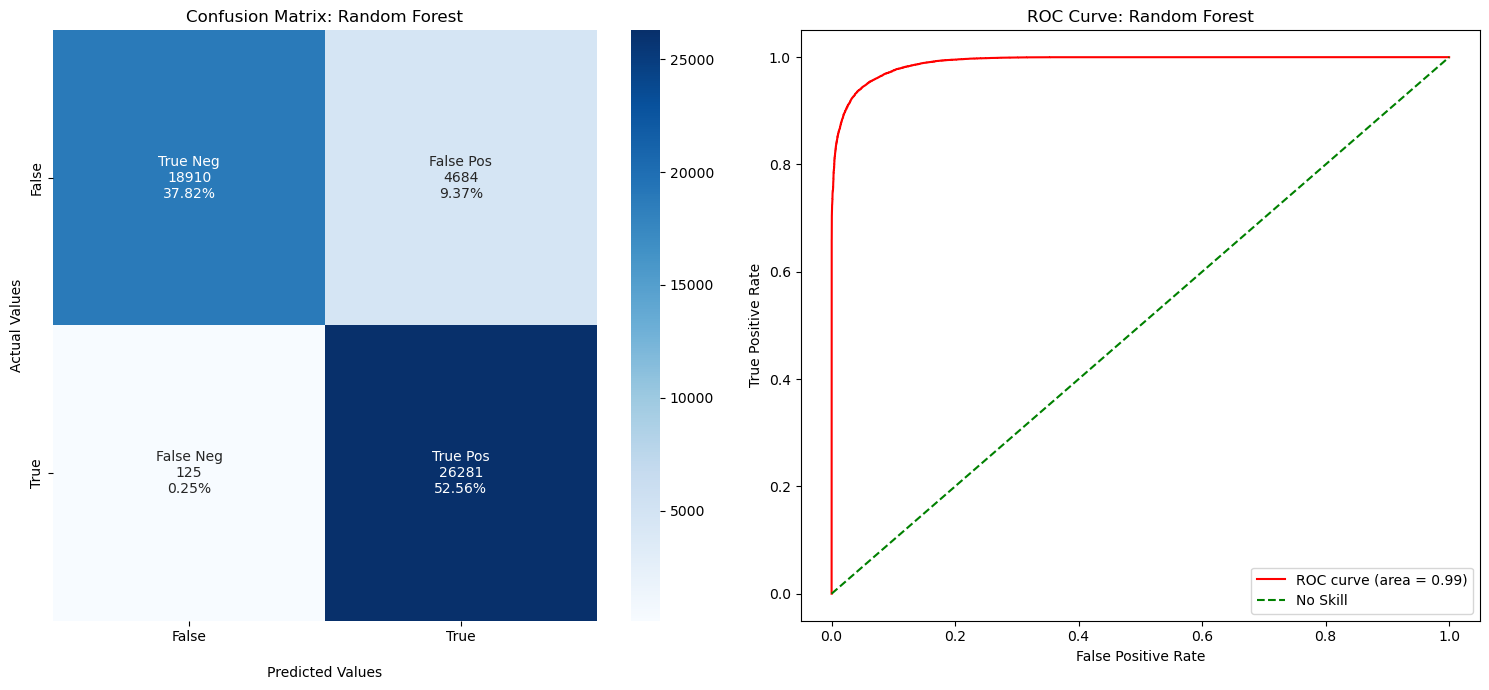

In [80]:
random_forest_pipeline(df_aln_shuffle)

## XGBOOST

In [81]:
def gradient_boosting_pipeline(data, target_column='z-score calculated from 7. 8. and 9.', threshold=0, class_weights={0: 1, 1: 3}):
    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    
    # Standardisierung des z-scores
    data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score"] > threshold, 1, 0)
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Gradient Boosting (XGBoost) trainieren
    gb_model = XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=class_weights[1], random_state=0)
    gb_model.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(gb_model, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = gb_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)

    if cm.shape == (2,2):  # Prüfe, ob die Confusion Matrix 2x2 ist
        false_negative_rate = 1 - cm[1][0] / (cm[1][0] + cm[1][1])
        print("False-Negative Rate: ", false_negative_rate)
    else:
        print("Warnung: Nur eine Klasse in y_test vorhanden, False-Negative Rate nicht berechenbar.")

    # Schritt 5: ROC-Kurve und AUC berechnen
    global y_test_prob
    y_test_prob = gb_model.predict_proba(X_test)[:, 1]
    fper, tper, _ = roc_curve(y_test, y_test_prob)

    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, "Confusion Matrix: Gradient Boosting", ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, "ROC Curve: Gradient Boosting", ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()
    plt.show()

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    27777
0    22223
Name: count, dtype: int64
y_test label
1    27834
0    22166
Name: count, dtype: int64
Cross-validation scores: [0.9918 0.9896 0.9906 0.9912 0.993  0.9904 0.9922 0.9928 0.9904 0.9918]
Mean CV score: 0.9913799999999998
Accuracy score:  0.99062
False-Negative Rate:  0.9960479988503269


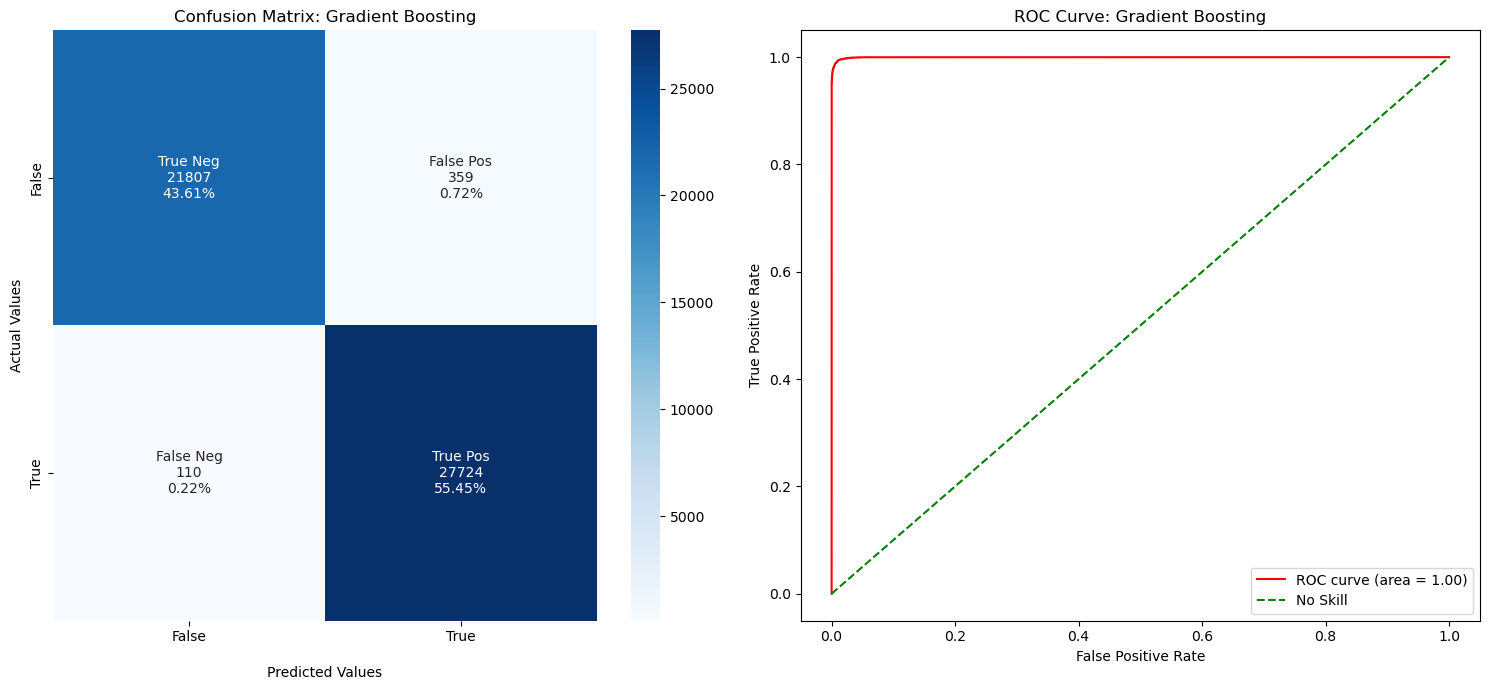

In [82]:
gradient_boosting_pipeline(df_sissiz_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    27273
0    22727
Name: count, dtype: int64
y_test label
1    27264
0    22736
Name: count, dtype: int64
Cross-validation scores: [0.9922 0.9906 0.9906 0.9868 0.9908 0.9896 0.9898 0.991  0.9932 0.992 ]
Mean CV score: 0.9906600000000001
Accuracy score:  0.99034
False-Negative Rate:  0.9953051643192489


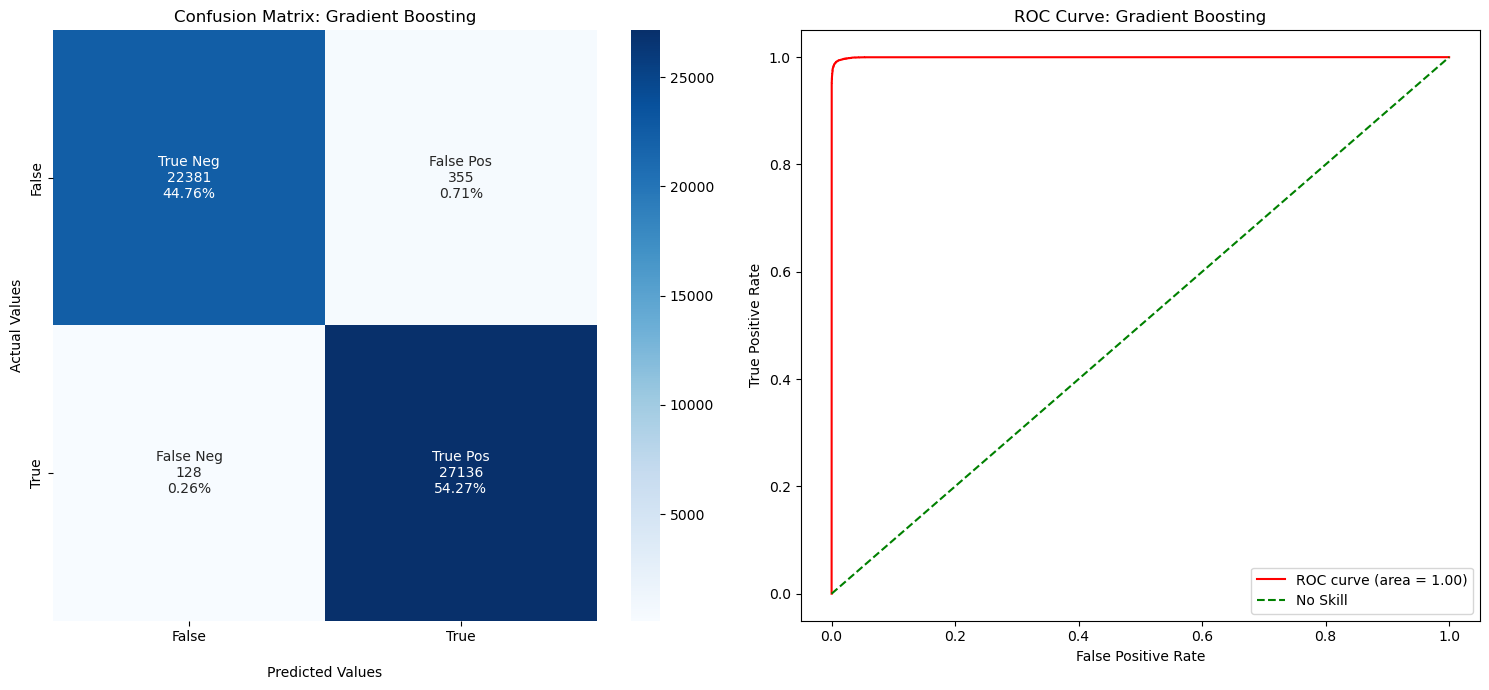

In [83]:
gradient_boosting_pipeline(df_sissiz_di)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26429
0    23571
Name: count, dtype: int64
y_test label
1    26484
0    23516
Name: count, dtype: int64
Cross-validation scores: [0.9908 0.99   0.993  0.989  0.9912 0.992  0.9936 0.9902 0.9896 0.9894]
Mean CV score: 0.99088
Accuracy score:  0.99088
False-Negative Rate:  0.9967149977344812


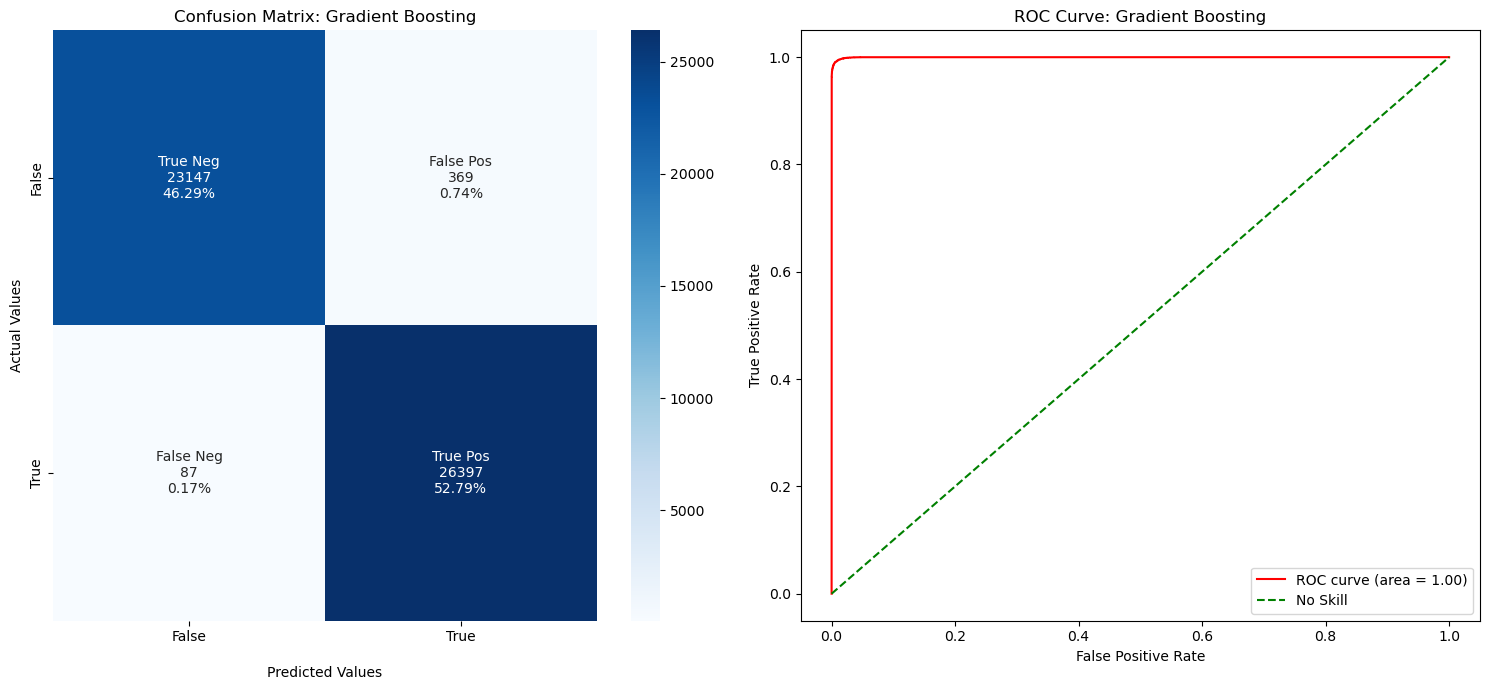

In [84]:
gradient_boosting_pipeline(df_multiperm_mono)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26380
0    23620
Name: count, dtype: int64
y_test label
1    26392
0    23608
Name: count, dtype: int64
Cross-validation scores: [0.99   0.991  0.9896 0.9904 0.9928 0.99   0.991  0.9878 0.9922 0.9882]
Mean CV score: 0.9902999999999998
Accuracy score:  0.99016
False-Negative Rate:  0.9958320703243407


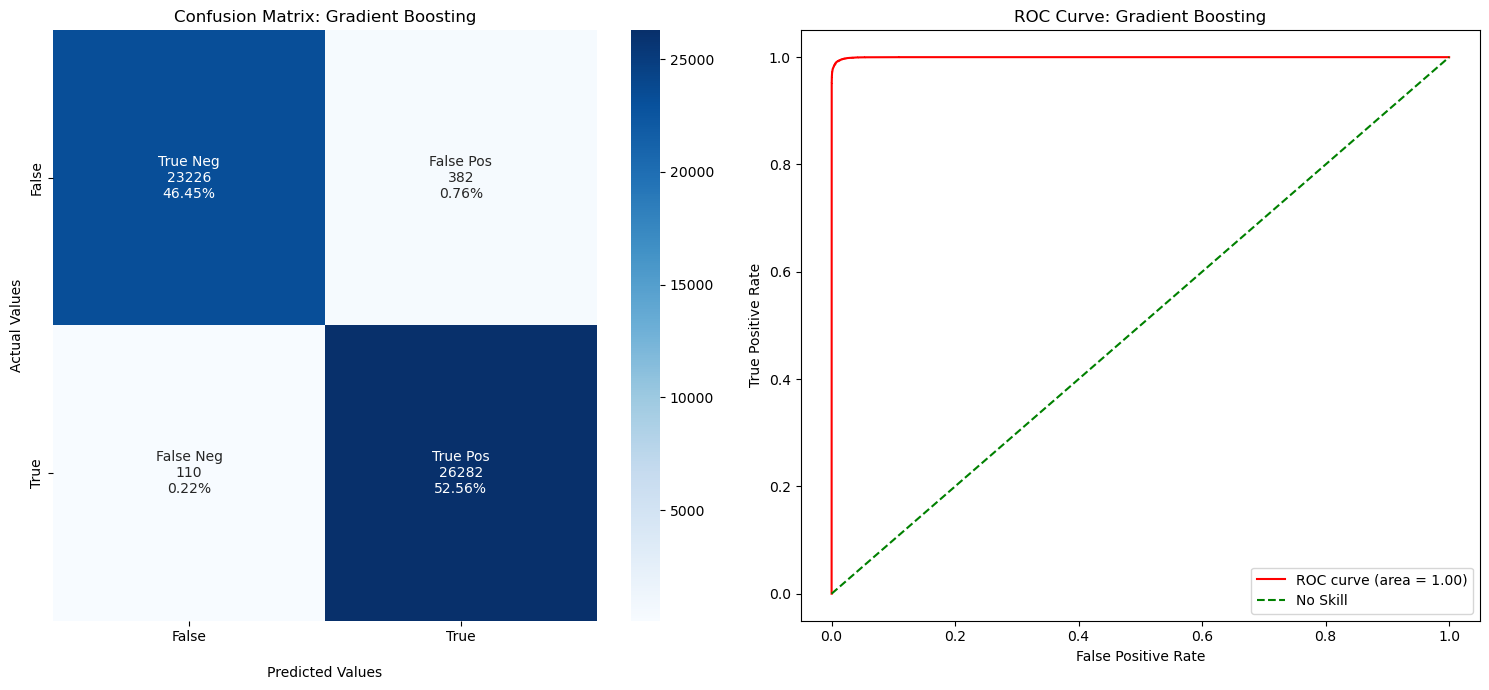

In [85]:
gradient_boosting_pipeline(df_multiperm_di)

X_train: (50000, 8)
y_train: (50000,)
X_test: (50000, 8)
y_test: (50000,)
y_train label
1    26450
0    23550
Name: count, dtype: int64
y_test label
1    26406
0    23594
Name: count, dtype: int64
Cross-validation scores: [0.9932 0.9922 0.9898 0.9934 0.9894 0.9926 0.9928 0.9916 0.992  0.9912]
Mean CV score: 0.9918199999999999
Accuracy score:  0.99222
False-Negative Rate:  0.9970082556994623


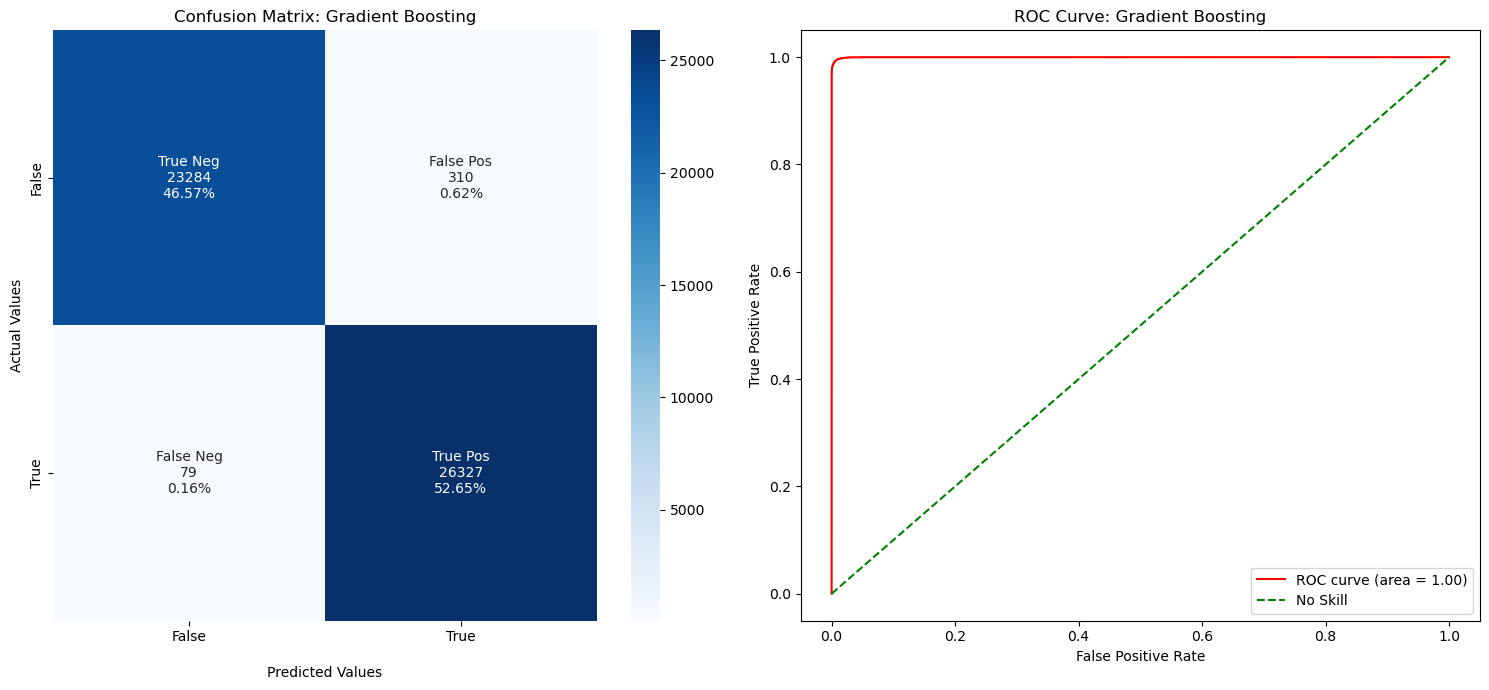

In [86]:
gradient_boosting_pipeline(df_aln_shuffle)